# Lab 2 — Isolation Forest vs Autoencoder with Embeddings

This notebook provides a self-contained login-anomaly example aligned with the lecture:

- **Isolation Forest** detects rare feature-space outliers.
- **Autoencoder with embeddings** learns normal behavioral combinations.
- The final section compares the models and inspects disagreements.

The synthetic scenario is related to **MITRE ATT&CK T1078 (Valid Accounts)** and **T1110 (Brute Force)**.


> **Interpretation guidance:** Explanatory comments are included after each results section to help connect the metrics and visualizations to SOC decision-making.


In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support
)
from sklearn.decomposition import PCA

import keras
from keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Keras backend:", keras.backend.backend())


Keras backend: torch


## 1. Generate synthetic login telemetry

Normal records follow stable user, device, country and working-hour patterns. Attack records introduce unusual combinations such as late-night access, new countries, unknown devices and repeated failures.


In [2]:
N_NORMAL = 3800
N_ATTACK = 160

users = ["analyst01", "analyst02", "finance01", "developer01", "admin01"]
usual_country = {
    "analyst01": "IL", "analyst02": "IL", "finance01": "IL",
    "developer01": "IL", "admin01": "IL"
}
usual_device = {
    "analyst01": "managed_laptop", "analyst02": "managed_laptop",
    "finance01": "managed_laptop", "developer01": "developer_workstation",
    "admin01": "admin_workstation"
}

rows = []
for _ in range(N_NORMAL):
    user = np.random.choice(users, p=[0.25, 0.20, 0.20, 0.25, 0.10])
    rows.append({
        "user": user,
        "country": usual_country[user],
        "device": usual_device[user],
        "protocol": np.random.choice(["HTTPS", "VPN", "SSH"], p=[0.60, 0.32, 0.08]),
        "hour": int(np.clip(np.random.normal(12.5, 2.5), 6, 21)),
        "failed_attempts": np.random.poisson(0.25),
        "distance_km": abs(np.random.normal(8, 12)),
        "session_minutes": max(1, np.random.gamma(3.5, 12)),
        "bytes_out_mb": max(0.1, np.random.lognormal(2.0, 0.6)),
        "is_attack": 0
    })

for _ in range(N_ATTACK):
    user = np.random.choice(users)
    rows.append({
        "user": user,
        "country": np.random.choice(["RU", "CN", "SG", "US", "DE"]),
        "device": np.random.choice(["unknown", "mobile", "unmanaged_laptop"]),
        "protocol": np.random.choice(["HTTPS", "VPN", "SSH"]),
        "hour": np.random.choice([0, 1, 2, 3, 4, 23]),
        "failed_attempts": np.random.randint(5, 18),
        "distance_km": np.random.uniform(800, 9000),
        "session_minutes": np.random.uniform(1, 20),
        "bytes_out_mb": np.random.lognormal(5.0, 0.7),
        "is_attack": 1
    })

df = pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(df.shape)
display(df.head())
display(df["is_attack"].value_counts().rename(index={0:"normal",1:"attack"}))


(3960, 10)


,user,country,device,protocol,hour,failed_attempts,distance_km,session_minutes,bytes_out_mb,is_attack
0,developer01,IL,developer_workstation,HTTPS,14,1,13.948183,115.895930,7.137972,0
1,analyst01,IL,managed_laptop,HTTPS,16,0,20.547952,54.179346,10.660855,0
2,analyst02,IL,managed_laptop,HTTPS,15,0,28.135590,40.337349,5.276849,0
3,analyst02,IL,managed_laptop,HTTPS,17,1,14.747003,56.774082,4.102999,0
4,finance01,IL,managed_laptop,VPN,10,1,14.617715,45.746867,20.057241,0


is_attack
normal    3800
attack     160
Name: count, dtype: int64

## 2. Exploratory analysis

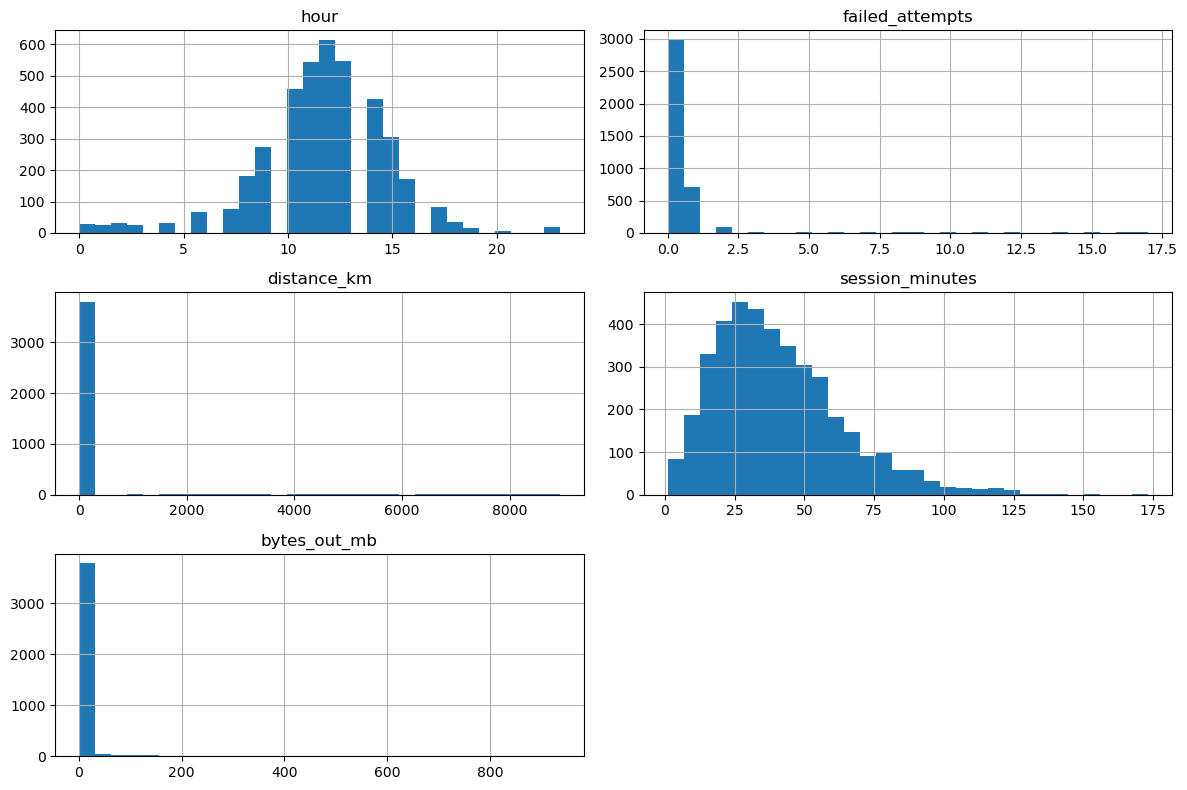

is_attack                0            1
hour             12.000000     2.000000
failed_attempts   0.000000    11.000000
distance_km      10.033474  4408.577160
session_minutes  37.992850     9.477511
bytes_out_mb      7.469846   149.085696


In [3]:
numeric_cols = [
    "hour", "failed_attempts", "distance_km",
    "session_minutes", "bytes_out_mb"
]
categorical_cols = ["user", "country", "device", "protocol"]

df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

print(df.groupby("is_attack")[numeric_cols].median().T)


### How to interpret the exploratory results

Use the histograms and the class-wise median table to identify which variables differ most between normal and attack events.

- A strong shift in **failed attempts**, **distance**, **session duration**, or **outbound traffic** suggests that those variables contain useful anomaly evidence.
- Similar medians do **not** mean that a feature is useless. An anomaly may be caused by a rare **combination** of otherwise normal values.
- Because attacks are the minority class, overall accuracy would be misleading. Later comparisons therefore emphasize precision, recall, F1, false positives, and false negatives.

**Question to ask:** Which features appear individually unusual, and which may only become suspicious when combined with user, device, country, or protocol?


## 3. Shared train, validation and test split

The autoencoder is trained only on normal training events. Labels are retained exclusively for evaluation and threshold analysis.


In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.40, stratify=df["is_attack"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["is_attack"], random_state=SEED
)

normal_train_df = train_df[train_df["is_attack"] == 0].copy()
normal_val_df = val_df[val_df["is_attack"] == 0].copy()

print("Train:", train_df.shape, "Normal-only AE train:", normal_train_df.shape)
print("Validation:", val_df.shape, "Test:", test_df.shape)


Train: (2376, 10) Normal-only AE train: (2280, 10)
Validation: (792, 10) Test: (792, 10)


## 4. Model A — Isolation Forest

In [5]:
if_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

X_if_train = if_preprocessor.fit_transform(train_df[numeric_cols + categorical_cols])
X_if_test = if_preprocessor.transform(test_df[numeric_cols + categorical_cols])
y_test = test_df["is_attack"].to_numpy()

iso = IsolationForest(
    n_estimators=300,
    contamination=float(train_df["is_attack"].mean()),
    random_state=SEED,
    n_jobs=-1
)
iso.fit(X_if_train)

if_score = -iso.decision_function(X_if_test)
if_pred = (iso.predict(X_if_test) == -1).astype(int)

print(confusion_matrix(y_test, if_pred))
print(classification_report(y_test, if_pred, target_names=["Normal", "Attack"]))


[[759   1]
 [  0  32]]
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       760
      Attack       0.97      1.00      0.98        32

    accuracy                           1.00       792
   macro avg       0.98      1.00      0.99       792
weighted avg       1.00      1.00      1.00       792



### Reading the Isolation Forest output

The confusion matrix follows this layout:

| | Predicted normal | Predicted attack |
|---|---:|---:|
| **Actually normal** | True negatives | False positives |
| **Actually attack** | False negatives | True positives |

Interpret the classification report as follows:

- **Attack precision:** among all alerts raised by Isolation Forest, how many were real attacks?
- **Attack recall:** among all real attacks, how many were detected?
- **Attack F1:** balance between precision and recall.
- **False positives:** normal events that would unnecessarily consume analyst time.
- **False negatives:** attacks that would remain undetected.

Isolation Forest is especially effective when an event is isolated in the transformed feature space, for example an extreme distance, many failed attempts, or a rare combination of one-hot encoded categories.


## 5. Model B — Autoencoder with categorical embeddings

Each categorical field is mapped to a trainable embedding. The decoder reconstructs:

- standardized numeric values using mean squared error;
- each categorical field using a softmax output.

The anomaly score combines numeric reconstruction error and categorical negative log likelihood.


In [6]:
# Numeric scaling
num_scaler = StandardScaler()
num_scaler.fit(normal_train_df[numeric_cols])

# Category encoders fitted on the full training partition, with an explicit unknown token
category_maps = {}
category_sizes = {}
for col in categorical_cols:
    values = sorted(train_df[col].astype(str).unique().tolist())
    category_maps[col] = {value: i + 1 for i, value in enumerate(values)}  # 0 = unknown
    category_sizes[col] = len(values) + 1

def prepare_ae_frame(frame):
    numeric = num_scaler.transform(frame[numeric_cols]).astype("float32")
    inputs = {"numeric": numeric}
    targets = {"numeric_out": numeric}
    for col in categorical_cols:
        indices = frame[col].astype(str).map(category_maps[col]).fillna(0).astype("int32").to_numpy()
        inputs[col] = indices
        targets[f"{col}_out"] = indices
    return inputs, targets

ae_train_inputs, ae_train_targets = prepare_ae_frame(normal_train_df)
ae_val_inputs, ae_val_targets = prepare_ae_frame(normal_val_df)
ae_test_inputs, ae_test_targets = prepare_ae_frame(test_df)


In [7]:
# Inputs
numeric_input = layers.Input(shape=(len(numeric_cols),), name="numeric")
model_inputs = {"numeric": numeric_input}
parts = [numeric_input]

for col in categorical_cols:
    inp = layers.Input(shape=(), dtype="int32", name=col)
    model_inputs[col] = inp
    emb_dim = min(8, max(2, int(np.ceil(np.sqrt(category_sizes[col])))))
    emb = layers.Embedding(category_sizes[col], emb_dim, name=f"{col}_embedding")(inp)
    parts.append(layers.Flatten()(emb))

combined = layers.Concatenate(name="combined_features")(parts)
hidden = layers.Dense(32, activation="relu")(combined)
latent = layers.Dense(8, activation="relu", name="behavior_embedding")(hidden)
decoded = layers.Dense(32, activation="relu")(latent)

outputs = {
    "numeric_out": layers.Dense(len(numeric_cols), name="numeric_out")(decoded)
}
for col in categorical_cols:
    outputs[f"{col}_out"] = layers.Dense(
        category_sizes[col], activation="softmax", name=f"{col}_out"
    )(decoded)

autoencoder = keras.Model(inputs=model_inputs, outputs=outputs)
encoder = keras.Model(inputs=model_inputs, outputs=latent)

losses = {"numeric_out": "mse"}
loss_weights = {"numeric_out": 1.0}
for col in categorical_cols:
    losses[f"{col}_out"] = "sparse_categorical_crossentropy"
    loss_weights[f"{col}_out"] = 0.35

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=losses,
    loss_weights=loss_weights
)
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country             │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ device (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protocol            │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 3)         │         18 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country_embedding   │ (None, 3)         │         21 │ country[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ device_embedding    │ (None, 3)         │         21 │ device[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protocol_embedding  │ (None, 2)         │          8 │ protocol[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric             │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3)         │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3)         │          0 │ country_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3)         │          0 │ device_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ protocol_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_features   │ (None, 16)        │          0 │ numeric[0][0],    │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        544 │ combined_feature… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behavior_embedding  │ (None, 8)         │        264 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ behavior_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country_out (Dense) │ (None, 7)         │        231 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ device_out (Dense)  │ (None, 7)         │        231 │ dense_1[0][0]   

 Total params: 2,121 (8.29 KB)

 Trainable params: 2,121 (8.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - country_out_loss: 1.8517 - device_out_loss: 1.9143 - loss: 3.4105 - numeric_out_loss: 0.9785 - protocol_out_loss: 1.4166 - user_out_loss: 1.7662 - val_country_out_loss: 1.7638 - val_device_out_loss: 1.8675 - val_loss: 3.3652 - val_numeric_out_loss: 0.9927 - val_protocol_out_loss: 1.3920 - val_user_out_loss: 1.7550
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - country_out_loss: 1.6600 - device_out_loss: 1.8074 - loss: 3.2033 - numeric_out_loss: 0.9014 - protocol_out_loss: 1.3706 - user_out_loss: 1.7389 - val_country_out_loss: 1.5125 - val_device_out_loss: 1.7388 - val_loss: 3.1274 - val_numeric_out_loss: 0.9170 - val_protocol_out_loss: 1.3420 - val_user_out_loss: 1.7223
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - country_out_loss: 1.3379 - device_out_loss: 1.6410 - loss: 2.9204 - numeric_out_loss: 0.8238 - protocol_out_loss: 1.3127 - user_out_loss: 1.6985 - val_country_out_loss: 1.0913 - val_device_out_loss: 1.5261 - v

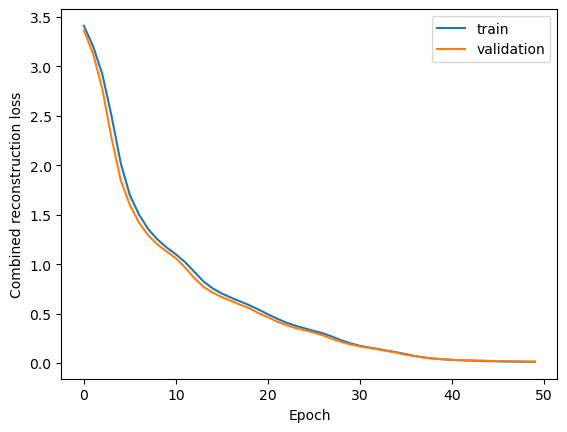

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
]

history = autoencoder.fit(
    ae_train_inputs,
    ae_train_targets,
    validation_data=(ae_val_inputs, ae_val_targets),
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Combined reconstruction loss")
plt.legend()
plt.show()


### Interpreting the training curve

Compare the training and validation reconstruction losses:

- Both curves decreasing suggests that the autoencoder is learning regular behavior.
- A validation curve that stops improving while training loss continues to fall indicates possible overfitting.
- A large persistent gap between the curves suggests that the model may not generalize well to unseen normal behavior.
- Early stopping restores the weights from the best validation epoch, so the final model is not necessarily the model from the last displayed epoch.

The absolute loss value is less important than stable convergence and similar behavior on the training and validation sets.


In [9]:
def ae_anomaly_scores(model, inputs, targets):
    predictions = model.predict(inputs, verbose=0)
    numeric_error = np.mean(
        np.square(targets["numeric_out"] - predictions["numeric_out"]), axis=1
    )

    categorical_error = np.zeros(len(numeric_error), dtype="float32")
    eps = 1e-8
    for col in categorical_cols:
        true_idx = targets[f"{col}_out"].astype(int)
        probs = predictions[f"{col}_out"]
        categorical_error += -np.log(probs[np.arange(len(true_idx)), true_idx] + eps)

    categorical_error /= len(categorical_cols)
    return numeric_error + 0.35 * categorical_error

normal_val_score = ae_anomaly_scores(autoencoder, ae_val_inputs, ae_val_targets)
ae_score = ae_anomaly_scores(autoencoder, ae_test_inputs, ae_test_targets)

threshold = np.percentile(normal_val_score, 99)
ae_pred = (ae_score > threshold).astype(int)

print("AE threshold:", threshold)
print(confusion_matrix(y_test, ae_pred))
print(classification_report(y_test, ae_pred, target_names=["Normal", "Attack"]))


AE threshold: 0.04420177
[[754   6]
 [  0  32]]
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       760
      Attack       0.84      1.00      0.91        32

    accuracy                           0.99       792
   macro avg       0.92      1.00      0.96       792
weighted avg       0.99      0.99      0.99       792



### Reading the autoencoder output

The autoencoder is trained only on normal events. It assigns a high anomaly score when it reconstructs an event poorly.

The score combines:

- numeric reconstruction error; and
- categorical reconstruction surprise from user, country, device, and protocol.

The threshold is the 99th percentile of reconstruction scores from normal validation events. Therefore, approximately 1% of validation-normal behavior is expected to exceed the threshold even without an attack.

Interpretation:

- **High recall with low precision:** sensitive detector, but many unnecessary alerts.
- **High precision with low recall:** conservative detector that misses more attacks.
- **Many false positives:** threshold may be too low or normal behavior may be diverse.
- **Many false negatives:** threshold may be too high or attacks may resemble normal behavior.

Changing the percentile directly changes the operational trade-off: lower percentiles raise more alerts; higher percentiles raise fewer alerts.


## 6. Quantitative comparison

In [10]:
def metric_row(name, pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="binary", zero_division=0
    )
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "model": name,
        "detected_anomalies": int(pred.sum()),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": int(fp),
        "false_negatives": int(fn)
    }

comparison = pd.DataFrame([
    metric_row("Isolation Forest", if_pred),
    metric_row("Autoencoder + embeddings", ae_pred)
]).set_index("model")

display(comparison.round(3))

agreement = np.mean(if_pred == ae_pred)
print(f"Agreement rate: {agreement:.2%}")
print("Both:", int(np.sum((if_pred == 1) & (ae_pred == 1))))
print("Isolation Forest only:", int(np.sum((if_pred == 1) & (ae_pred == 0))))
print("Autoencoder only:", int(np.sum((if_pred == 0) & (ae_pred == 1))))


,detected_anomalies,precision,recall,f1,false_positives,false_negatives
model,,,,,,
Isolation Forest,33,0.970,1.0,0.985,1,0
Autoencoder + embeddings,38,0.842,1.0,0.914,6,0


Agreement rate: 99.37%
Both: 33
Isolation Forest only: 0
Autoencoder only: 5


### How to compare the two methods

Use the table to answer different operational questions rather than declaring one universal winner:

- Prefer higher **recall** when missing an attack is the greatest risk.
- Prefer higher **precision** when analyst workload and alert fatigue are the main constraints.
- Prefer higher **F1** when precision and recall are equally important.
- Compare **false positives** and **false negatives** directly because they represent different operational costs.

The agreement statistics indicate complementarity:

- **Both models:** strongest candidates for analyst review.
- **Isolation Forest only:** globally isolated observations that the autoencoder reconstructed acceptably.
- **Autoencoder only:** observations that violate learned behavioral relationships even if no single feature is extreme.

A high agreement rate does not automatically mean better detection; it only means that the models often make the same decision.


In [11]:
# Automatic interpretation of the comparison table
best_precision = comparison["precision"].idxmax()
best_recall = comparison["recall"].idxmax()
best_f1 = comparison["f1"].idxmax()
fewest_fp = comparison["false_positives"].idxmin()
fewest_fn = comparison["false_negatives"].idxmin()

print("RESULT INTERPRETATION")
print("- Highest precision:", best_precision)
print("- Highest recall:", best_recall)
print("- Highest F1:", best_f1)
print("- Fewest false positives:", fewest_fp)
print("- Fewest false negatives:", fewest_fn)

if best_precision == best_recall == best_f1:
    print(f"\n{best_f1} is strongest on the main summary metrics for this run.")
else:
    print("\nNo single model dominates every criterion. Select a model according to the operational cost of false alerts versus missed attacks.")

print("\nRecommended triage rule:")
print("1. Prioritize events detected by both models.")
print("2. Review model-disagreement events manually.")
print("3. Treat events rejected by both as lower priority, not guaranteed benign.")


RESULT INTERPRETATION
- Highest precision: Isolation Forest
- Highest recall: Isolation Forest
- Highest F1: Isolation Forest
- Fewest false positives: Isolation Forest
- Fewest false negatives: Isolation Forest

Isolation Forest is strongest on the main summary metrics for this run.

Recommended triage rule:
1. Prioritize events detected by both models.
2. Review model-disagreement events manually.
3. Treat events rejected by both as lower priority, not guaranteed benign.


## 7. Original feature space versus behavioral embedding space

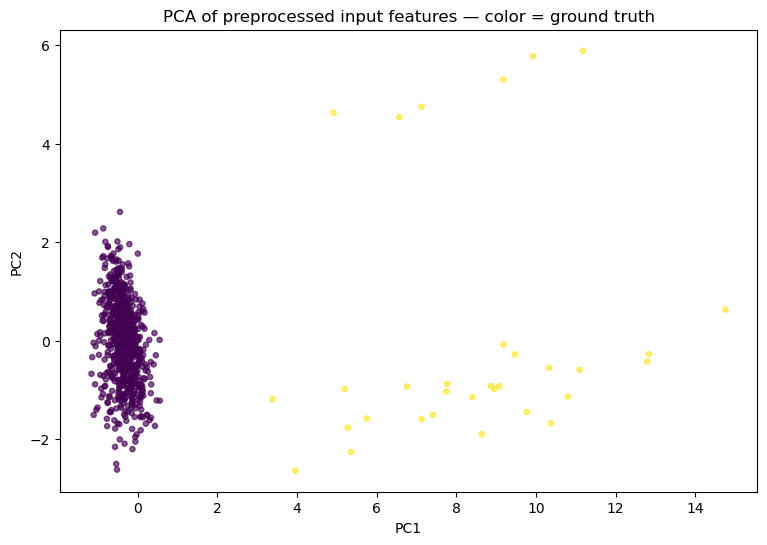

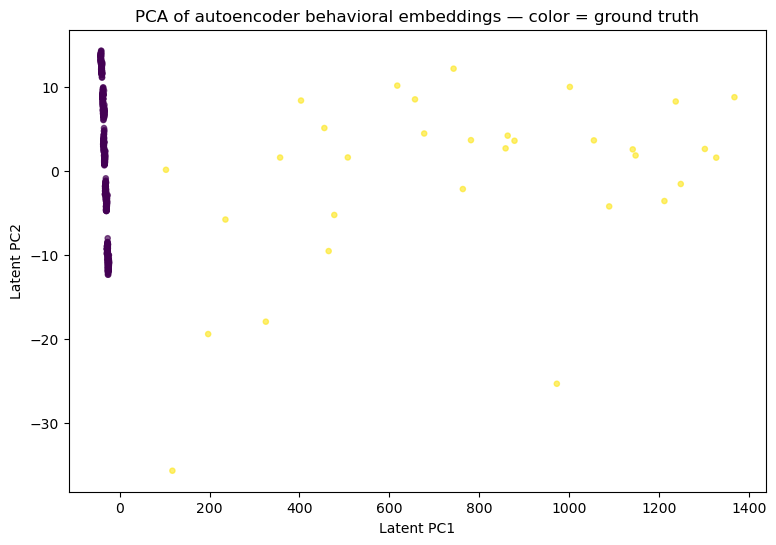

In [12]:
# PCA of Isolation Forest input space
pca_original = PCA(n_components=2, random_state=SEED)
xy_original = pca_original.fit_transform(X_if_test)

# PCA of learned latent behavioral embeddings
latent_vectors = encoder.predict(ae_test_inputs, verbose=0)
pca_latent = PCA(n_components=2, random_state=SEED)
xy_latent = pca_latent.fit_transform(latent_vectors)

plt.figure(figsize=(9, 6))
plt.scatter(xy_original[:, 0], xy_original[:, 1], c=y_test, s=14, alpha=0.65)
plt.title("PCA of preprocessed input features — color = ground truth")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure(figsize=(9, 6))
plt.scatter(xy_latent[:, 0], xy_latent[:, 1], c=y_test, s=14, alpha=0.65)
plt.title("PCA of autoencoder behavioral embeddings — color = ground truth")
plt.xlabel("Latent PC1")
plt.ylabel("Latent PC2")
plt.show()


### Interpreting the PCA visualizations

PCA compresses a high-dimensional representation into two dimensions. Therefore, these plots are diagnostic aids rather than proof of model quality.

- Clear separation between normal and attack points suggests that the representation contains useful anomaly structure.
- Overlap is expected because two principal components discard information.
- Better separation in the latent plot suggests that the autoencoder has learned a useful behavioral representation.
- Poor separation in the latent plot does not necessarily mean poor detection because the anomaly score is based on reconstruction error, not PCA distance.

Use the quantitative metrics as the primary evaluation and the plots to explain patterns.


## 8. Inspect model disagreements

In [13]:
results = test_df.copy()
results["if_score"] = if_score
results["if_pred"] = if_pred
results["ae_score"] = ae_score
results["ae_pred"] = ae_pred
results["models_agree"] = results["if_pred"] == results["ae_pred"]

disagreements = results[~results["models_agree"]].copy()
display(disagreements.sort_values(["ae_score", "if_score"], ascending=False).head(15))


,user,country,device,protocol,hour,failed_attempts,distance_km,session_minutes,bytes_out_mb,is_attack,if_score,if_pred,ae_score,ae_pred,models_agree
870,admin01,IL,admin_workstation,VPN,16,0,4.156354,12.158062,3.901917,0,-0.062123,0,0.160314,1,False
2688,admin01,IL,admin_workstation,HTTPS,9,0,22.362931,93.213104,4.188047,0,-0.067464,0,0.063459,1,False
372,analyst02,IL,managed_laptop,HTTPS,10,1,31.692761,13.494365,40.451243,0,-0.100038,0,0.056398,1,False
551,developer01,IL,developer_workstation,VPN,13,1,54.232778,62.229233,10.922608,0,-0.081340,0,0.053199,1,False
2975,developer01,IL,developer_workstation,HTTPS,11,2,0.642864,23.068715,25.930824,0,-0.091810,0,0.047717,1,False


### How to investigate disagreements

Disagreement records are the most informative cases for comparing the models.

For **Isolation Forest only** alerts, check whether one or more original features are extreme. The event may be globally isolated even though the autoencoder can reconstruct its overall pattern.

For **autoencoder only** alerts, check whether the event contains an unusual relationship such as:

- a familiar user with an unfamiliar device;
- a normal login hour from an unusual country;
- individually moderate values that form an abnormal behavioral combination.

For each disagreement, record:

1. which model raised the alert;
2. the strongest supporting evidence;
3. whether the event appears malicious, unusual but legitimate, or inconclusive;
4. whether an analyst should escalate, request more evidence, or close the alert.

Do not assume that either model is automatically correct. Ground truth is available here for evaluation, but in a real SOC the disagreement would require investigation.


## 9. Student interpretation

Select at least three disagreement records and answer:

1. Which model raised the alert?
2. What evidence supports the alert?
3. Could the event be a legitimate exception?
4. Would you accept, challenge, or escalate the alert?
5. Which MITRE ATT&CK technique is most relevant?

## 10. Conclusion

Compare the models in terms of:

- precision and recall;
- false positives and false negatives;
- anomaly types detected;
- usefulness of behavioral embeddings;
- limitations of training only on synthetic or incomplete normal data.
